|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>Understand and design CNNs<h1>|
|<h2>Lecture:</h2>|<h1><b>The EMNIST dataset (letter recognition)<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import os
import copy
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split
from torchsummary import summary

# for importing data
import torchvision

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

In [2]:
# use GPU if available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Import and inspect the data

In [3]:
# download the dataset
cdata = torchvision.datasets.EMNIST(root='../sample_data/emnist',
                                    split='letters',download=True)

# more info: https://www.nist.gov/itl/products-and-services/emnist-dataset

In [4]:
# inspect the data

# the categories (but how many letters??)
print(cdata.classes)
print(str(len(cdata.classes)) + ' classes')

print('\nData size:')
print(cdata.data.shape)

# transform to 4D tensor for conv layers (and transform from int8 to dtype=torch.bfloat16)
dtype=torch.bfloat16
images = cdata.data.view([124800,1,28,28]).to(dtype=dtype)
print('\nTensor data:')
print(images.shape)


['N/A', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
27 classes

Data size:
torch.Size([124800, 28, 28])

Tensor data:
torch.Size([124800, 1, 28, 28])


In [5]:
# brief aside: class 'N/A' doesn't exist in the data.
print( torch.sum(cdata.targets==0) )

# However, it causes problems in one-hot encoding...
torch.unique(cdata.targets)

tensor(0)


tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
        19, 20, 21, 22, 23, 24, 25, 26])

In [6]:
cdata.class_to_idx

{'N/A': 0,
 'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26}

In [7]:
# so therefore we'll eliminate it and subtract 1 from the original

# remove the first class category
letterCategories = cdata.classes[1:]

# relabel labels to start at 0
labels = copy.deepcopy(cdata.targets)-1
print(labels.shape)

###
print( torch.sum(labels==0) )
torch.unique(labels)

torch.Size([124800])
tensor(4800)


tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25])

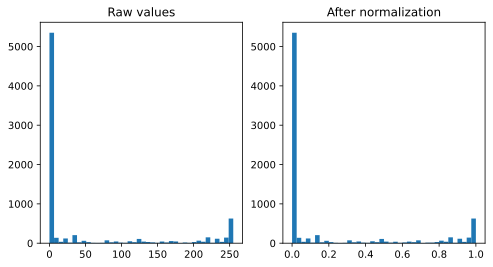

In [8]:
# next issue: do we need to normalize the images?
fig, axs = plt.subplots(1,2, figsize=(8,4))
axs[0].hist(torch.squeeze(images[:10,:,:,:]).to(torch.float32).flatten().detach().numpy(), 40)
axs[0].set_title('Raw values')

# yarp.
images = (images - torch.min(images)) / (torch.max(images) - torch.min(images))

axs[1].hist(torch.squeeze(images[:10,:,:,:]).to(torch.float32).flatten().detach().numpy(), 40)
axs[1].set_title('After normalization')

plt.show()

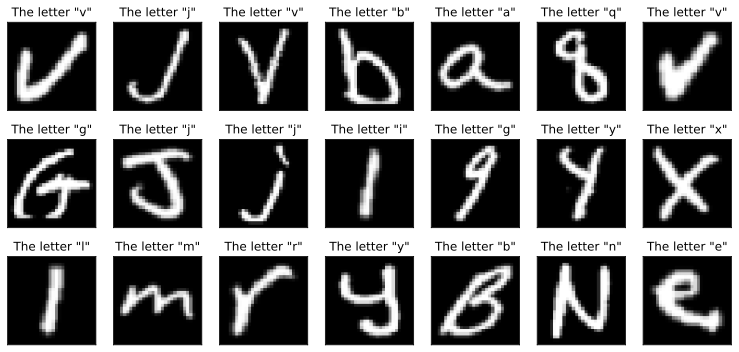

In [9]:
# visualize some images
fig,axs = plt.subplots(3,7,figsize=(13,6))

for i,ax in enumerate(axs.flatten()):

  # pick a random pic
  whichpic = np.random.randint(images.shape[0])

  # extract the image and its target letter
  I = np.squeeze( images[whichpic,:,:] ).to(torch.float32)
  letter = letterCategories[labels[whichpic]]

  # visualize
  ax.imshow(I.T,cmap='gray')
  ax.set_title('The letter "%s"'%letter)
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# Create train/test groups using DataLoader

In [54]:
# Step 2: use scikitlearn to split the data
train_data,test_data, train_labels,test_labels = train_test_split(images, labels, test_size=.1)

# Step 3: convert into PyTorch Datasets
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)

# Step 4: translate into dataloader objects
batchsize    = 64
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

In [55]:
# check size (should be images X channels X width X height
print( train_loader.dataset.tensors[0].shape )
print( train_loader.dataset.tensors[1].shape )

torch.Size([112320, 1, 28, 28])
torch.Size([112320])


# Create the DL model

In [56]:
# create a class for the model
def makeTheNet(printtoggle=False, dtype=torch.bfloat16):

  class emnistnet(nn.Module):
    def __init__(self,printtoggle,dtype):
      super().__init__()

      # print toggle
      self.print = printtoggle
      self.dtype = dtype
      
      self.inSize = 28
      self.pool2d_kernel_sz = 2
      
      self.p_drop = .2
      
      # For equation see: https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
      CNNLayerOutSize = lambda inSize, p, kzs, s, psz: int(np.ceil((inSize + 2*p - kzs)//s + 1)//psz)

      ### -------------- feature map layers -------------- ###
      # first convolution layer
      self.conv1  = nn.Conv2d(1,128,5,padding=1, dtype=self.dtype)
      self.bnorm1 = nn.BatchNorm2d(self.conv1.out_channels, dtype=self.dtype) # input the number of channels in this layer
      # output size: (28+2*1-3)/1 + 1 = 28/2 = 14 (/2 b/c pool2d)
      nOutCNNLayer1 =  CNNLayerOutSize(self.inSize, self.conv1.padding[0], self.conv1.kernel_size[0], self.conv1.stride[0], self.pool2d_kernel_sz)
      if self.print: print(f'nOutCNNLayer1: {nOutCNNLayer1}')

      # second convolution layer
      self.conv2  = nn.Conv2d(self.conv1.out_channels,512,3,padding=1, dtype=self.dtype)
      self.bnorm2 = nn.BatchNorm2d(self.conv2.out_channels, dtype=self.dtype) # input the number of channels in this layer
      # output size: (14+2*1-3)/1 + 1 = 14/2 = 7 (/2 b/c pool2d)
      nOutCNNLayer2 = CNNLayerOutSize(nOutCNNLayer1, self.conv2.padding[0], self.conv2.kernel_size[0], self.conv2.stride[0], self.pool2d_kernel_sz)
      if self.print: print(f'nOutCNNLayer2: {nOutCNNLayer2}')

      ### -------------- linear decision layers -------------- ###
      self.fc1 = nn.Linear(nOutCNNLayer2*nOutCNNLayer2*self.conv2.out_channels, 512, dtype=self.dtype)
      self.bnorm_fc1 = nn.BatchNorm1d(self.fc1.out_features, dtype=self.dtype)
      
      self.fc_out = nn.Linear(self.fc1.out_features, 26, dtype=self.dtype)
      self.bnorm_fc_out = nn.BatchNorm1d(self.fc_out.out_features, dtype=self.dtype)

    def forward(self,x):

      if self.print: print(f'Input: {list(x.shape)}')

      # first block: convolution -> maxpool -> batchnorm -> relu
      x = F.max_pool2d(self.conv1(x),self.pool2d_kernel_sz)
      x = F.relu(self.bnorm1(x))
      x = F.dropout(x, p=self.p_drop, training=self.training)
      if self.print: print(f'First CPR block: {list(x.shape)}')

      # second block: convolution -> maxpool -> batchnorm -> relu
      x = F.max_pool2d(self.conv2(x),self.pool2d_kernel_sz)
      x = F.relu(self.bnorm2(x))
      x = F.dropout(x, p=self.p_drop, training=self.training)
      if self.print: print(f'Second CPR block: {list(x.shape)}')

      # reshape for linear layer
      x = x.flatten(start_dim=1)
      if self.print: print(f'Vectorized: {list(x.shape)}')
      
      # linear layers
      x = F.relu(self.bnorm_fc1(self.fc1(x)))
      x = F.dropout(x, p=self.p_drop, training=self.training)
      if self.print: print(f'fc1 output: {list(x.shape)}')

      x = F.softmax(self.bnorm_fc_out(self.fc_out(x)), dim=1, dtype=self.dtype)
      if self.print: print(f'Final output: {list(x.shape)}')

      return x
    
    @staticmethod
    def accuracy(yHat, y):
      return torch.mean((torch.argmax(yHat,axis=1) == y).float()).item()
    
    @staticmethod
    def error_rate(yHat, y):
      return 1.0 - emnistnet.accuracy(yHat, y)

  # create the model instance
  net = emnistnet(printtoggle,dtype=dtype)

  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer
  optimizer = torch.optim.Adam(net.parameters(),lr=.01)  # ,weight_decay=1e-8)

  return net,lossfun,optimizer

In [57]:
# test the model with one batch
net,lossfun,optimizer = makeTheNet(True, dtype=dtype)

X,y = next(iter(train_loader))
yHat = net(X)

# check size of output
print('\nOutput size:')
print(yHat.shape)

# # now let's compute the loss
loss = lossfun(yHat,torch.squeeze(y))
print(' ')
print('Loss:')
print(loss)

nOutCNNLayer1: 13
nOutCNNLayer2: 6
Input: [64, 1, 28, 28]
First CPR block: [64, 128, 13, 13]
Second CPR block: [64, 512, 6, 6]
Vectorized: [64, 18432]
fc1 output: [64, 512]
Final output: [64, 26]

Output size:
torch.Size([64, 26])
 
Loss:
tensor(3.2500, dtype=torch.bfloat16, grad_fn=<NllLossBackward0>)


In [58]:
net_summary,_,_ = makeTheNet(dtype=torch.float)
summary(net_summary,(1,28,28), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 128, 26, 26]           3,328
       BatchNorm2d-2          [-1, 128, 13, 13]             256
            Conv2d-3          [-1, 512, 13, 13]         590,336
       BatchNorm2d-4            [-1, 512, 6, 6]           1,024
            Linear-5                  [-1, 512]       9,437,696
       BatchNorm1d-6                  [-1, 512]           1,024
            Linear-7                   [-1, 26]          13,338
       BatchNorm1d-8                   [-1, 26]              52
Total params: 10,047,054
Trainable params: 10,047,054
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 1.63
Params size (MB): 38.33
Estimated Total Size (MB): 39.96
----------------------------------------------------------------


# Create a function that trains the model

In [59]:
# a function that trains the model

def function2trainTheModel(train_loader, test_loader, dtype,numepochs:int=10):
  # create a new model
  net,lossfun,optimizer = makeTheNet(dtype=dtype)

  # send the model to the GPU
  net.to(device)

  # initialize losses
  trainLoss = torch.zeros(numepochs)
  testLoss  = torch.zeros(numepochs)
  trainErr  = torch.zeros(numepochs)
  testErr   = torch.zeros(numepochs)

  # loop over epochs
  for epochi in range(numepochs):

    # loop over training data batches
    net.train()
    
    numBatchElems = train_loader.dataset.tensors[0].shape[0] // train_loader.batch_size
    batchLoss = torch.zeros(numBatchElems)
    batchErr  = torch.zeros(numBatchElems)
    
    for batchi,(X,y) in enumerate(train_loader):

      # push data to GPU
      X = X.to(device)
      y = y.to(device)

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss and error from this batch
      batchLoss[batchi] = loss.item()
      batchErr[batchi]  = net.error_rate(yHat,y)
    # end of batch loop...

    # and get average losses and error rates across the batches
    trainLoss[epochi] = torch.mean(batchLoss)
    trainErr[epochi]  = 100*torch.mean(batchErr)

    ### test performance
    net.eval()
    X,y = next(iter(test_loader)) # extract X,y from test dataloader

    # push data to GPU
    X = X.to(device)
    y = y.to(device)

    with torch.no_grad(): # deactivates autograd
      yHat = net(X)
      loss = lossfun(yHat,y)

    # get loss and error rate from the test batch
    testLoss[epochi] = loss.item()
    testErr[epochi]  = 100*net.error_rate(yHat,y)
    
    print(f'Epoch {epochi+1}/{numepochs}  '
          f'Train Loss: {trainLoss[epochi]:.4f}  '
          f'Test Loss: {testLoss[epochi]:.4f}  '
          f'Train Err: {trainErr[epochi]:.2f}%  '
          f'Test Err: {testErr[epochi]:.2f}%', end='\r')

  # end epochs

  # function output
  return trainLoss,testLoss,trainErr,testErr,net

# Run the model and show the results!

In [60]:
# ~2 minutes with 10 epochs on GPU (8 mins on the CPU!)
trainLoss,testLoss,trainErr,testErr,net = function2trainTheModel(train_loader, test_loader, numepochs=10, dtype=dtype)

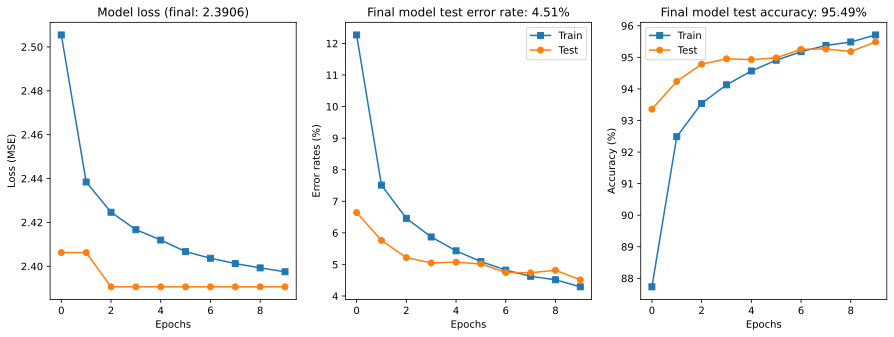

In [61]:
fig,ax = plt.subplots(1,3,figsize=(15,5))

ax[0].plot(trainLoss,'s-',label='Train')
ax[0].plot(testLoss,'o-',label='Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss (MSE)')
ax[0].set_title(f'Model loss (final: {testLoss[-1]:.4f})')

ax[1].plot(trainErr,'s-',label='Train')
ax[1].plot(testErr,'o-',label='Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Error rates (%)')
ax[1].set_title(f'Final model test error rate: {testErr[-1]:.2f}%')
ax[1].legend()

ax[2].plot(100 - trainErr,'s-',label='Train')
ax[2].plot(100 - testErr,'o-',label='Test')
ax[2].set_xlabel('Epochs')
ax[2].set_ylabel('Accuracy (%)')
ax[2].set_title(f'Final model test accuracy: {100 - testErr[-1]:.2f}%')
ax[2].legend()

plt.show()

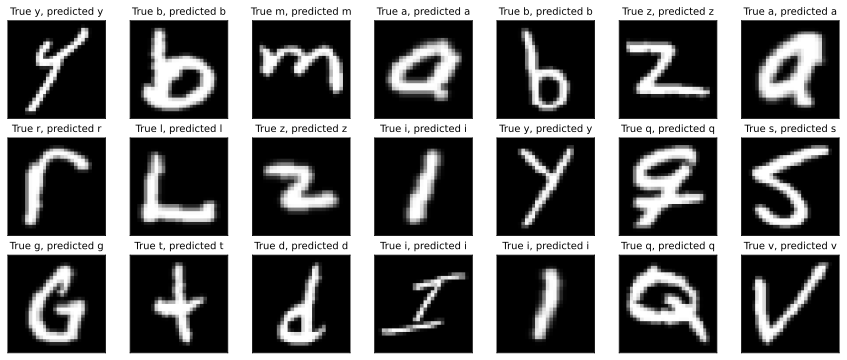

In [62]:
### visualize some images

# extract X,y from test dataloader
X,y = next(iter(test_loader))
X = X.to(device) # push data to GPU
y = y.to(device) # push data to GPU
yHat = net(X)

# pick some examples at random to show
randex = np.random.choice(len(y),size=21,replace=False)

# visualize some images
fig,axs = plt.subplots(3,7,figsize=(15,6))

for i,ax in enumerate(axs.flatten()):

  # extract the image and its target letter
  I = np.squeeze( X[randex[i],0,:,:] ).cpu().to(torch.float32) # .cpu() to transfer back from GPU!
  trueLetter = letterCategories[ y[randex[i]] ]
  predLetter = letterCategories[ torch.argmax(yHat[randex[i],:]) ]

  # color-code the accuracy (using ternary operator)
  col = 'gray' if trueLetter==predLetter else 'hot'

  # visualize
  ax.imshow(I.T,cmap=col)
  ax.set_title('True %s, predicted %s' %(trueLetter,predLetter),fontsize=10)
  ax.set_xticks([])
  ax.set_yticks([])

plt.show()

# Accuracy by letter

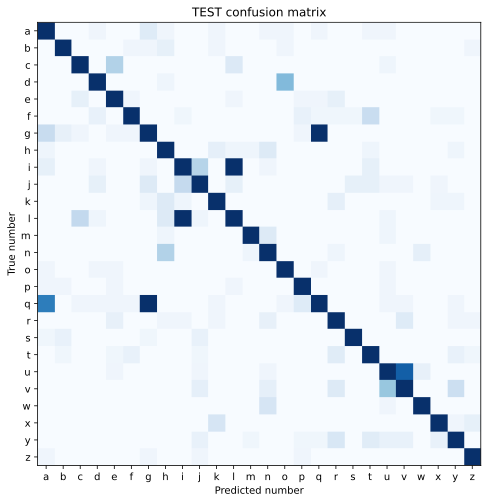

In [63]:
import sklearn.metrics as skm

# compute the confusion matrix
C = skm.confusion_matrix(y.cpu(),torch.argmax(yHat.cpu(),axis=1),normalize='true')

# visualize it
fig = plt.figure(figsize=(8,8))
plt.imshow(C,'Blues',vmax=.05)

# make the plot look nicer
plt.xticks(range(26),labels=letterCategories)
plt.yticks(range(26),labels=letterCategories)
plt.title('TEST confusion matrix')
plt.xlabel('True number')
plt.xlabel('Predicted number')
plt.ylabel('True number')

plt.show()

# Additional explorations

In [64]:
# 1) I added batch normalization to the convolution layers, but not to the linear (fc*) layers. But linear layers also
#    benefit from batchnorm just like convolution layers do. Add it!
#
# 2) In the next few videos, we will see whether we can improve the model's performance by experimenting with the number
#    of layers, kernel size, and linear-layer units. Is there anything you could think of, other than these three features,
#    that might help boost model performance?
# Answer: 
# - Adding dropout layers to prevent overfitting
# - Adding layer normalization
# - Changing learning rate
#